In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os

parent_path = "C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps"

FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])
rul_df['unit_number'] = rul_df.index + 1 # 엔진 번호(1부터 시작) 추가

train_df

Train path: C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps\train_FD001.txt


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


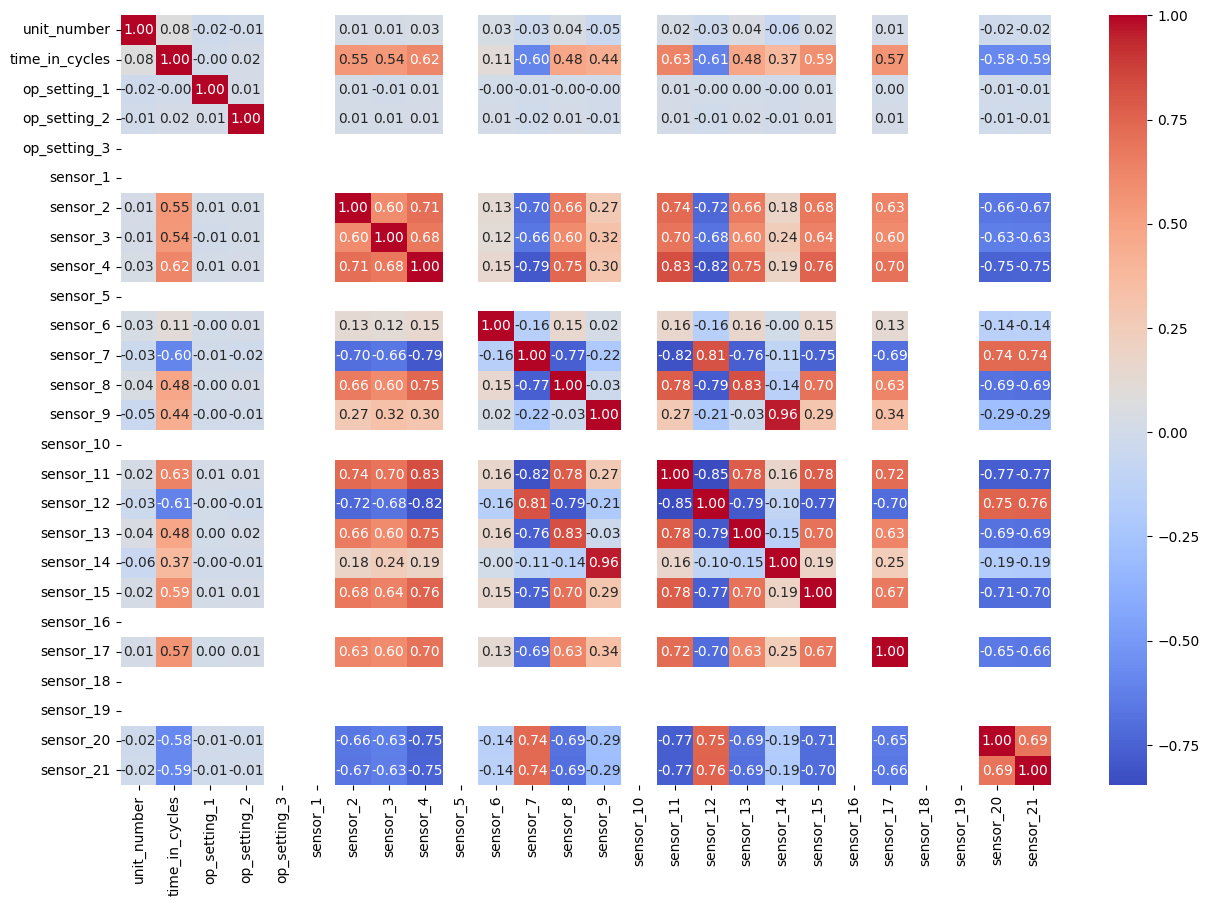

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

#corr = df.corr()

#rul_corr = corr['RUL'].sort_values(ascending=False)

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

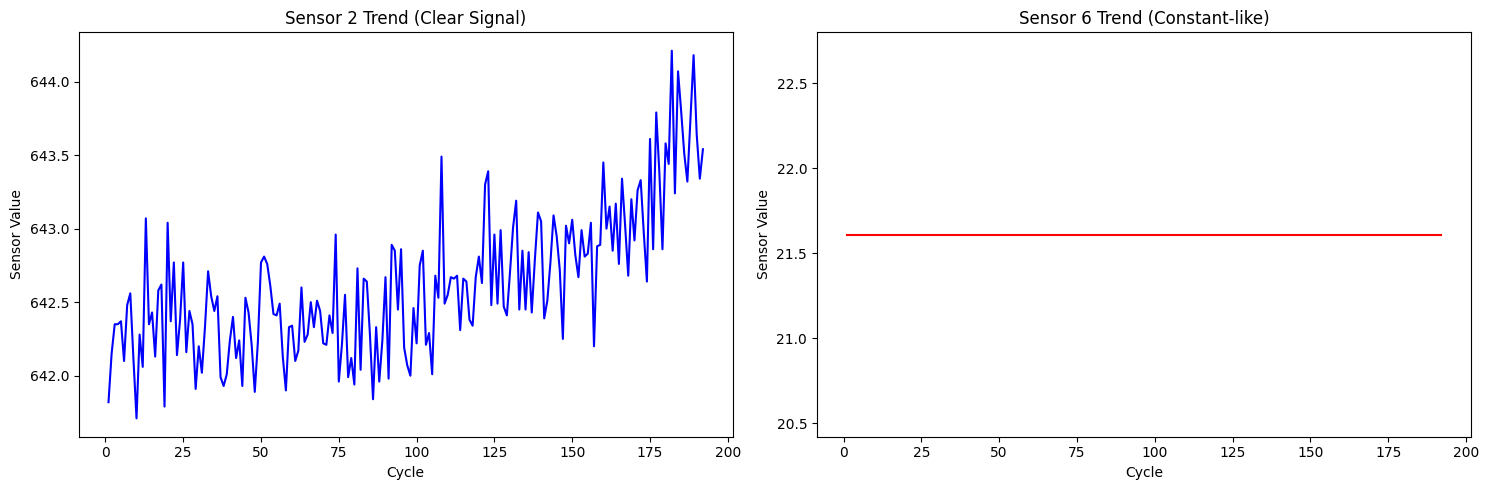

In [27]:
import matplotlib.pyplot as plt

# 1. 1번 엔진 데이터만 추출
engine_1 = train_df[train_df['unit_number'] == 1]

# 2. 시각화 시작
plt.figure(figsize=(15, 5))

# 변화가 뚜렷한 센서 (비교군: 센서 2번)
plt.subplot(1, 2, 1)
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_2'], color='blue')
plt.title('Sensor 2 Trend (Clear Signal)')
plt.xlabel('Cycle')
plt.ylabel('Sensor Value')

# 궁금하신 6번 센서 (확인군)
plt.subplot(1, 2, 2)
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_6'], color='red')
plt.title('Sensor 6 Trend (Constant-like)')
plt.xlabel('Cycle')
plt.ylabel('Sensor Value')

plt.tight_layout()
plt.show()

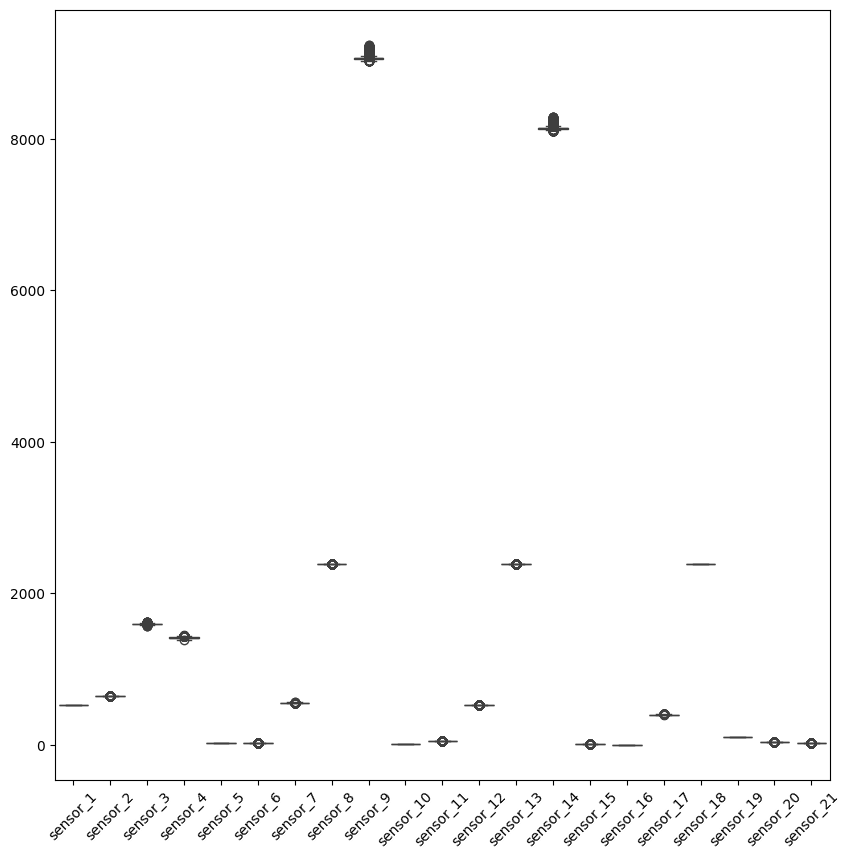

In [28]:
plt.figure(figsize=(10,10))
sns.boxplot(data=train_df.iloc[:, 5:26])
plt.xticks(rotation=45)
plt.show()

In [30]:
print(train_df['sensor_6'].value_counts())

sensor_6
21.61    20225
21.60      406
Name: count, dtype: int64


In [ ]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0_0.0_100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,0.0_0.0_100.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,0.0_0.0_100.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,0.0_0.0_100.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,0.0_0.0_100.0


In [20]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   Alt[kft]        20631 non-null  float64
 3   Mn[-]           20631 non-null  float64
 4   TLA[deg]        20631 non-null  float64
 5   T2[R]           20631 non-null  float64
 6   T24[R]          20631 non-null  float64
 7   T30[R]          20631 non-null  float64
 8   T50[R]          20631 non-null  float64
 9   P2[psi]         20631 non-null  float64
 10  P15[psi]        20631 non-null  float64
 11  P30[psi]        20631 non-null  float64
 12  Nf[rpm]         20631 non-null  float64
 13  Nc[rpm]         20631 non-null  float64
 14  epr[-]          20631 non-null  float64
 15  phi[pph/psi]    20631 non-null  float64
 16  Ps30[psi]       20631 non-null  float64
 17  NRf[rpm]        20631 non-null 

In [21]:
train_df.describe()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Ps30[psi],NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s]
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [22]:
train_df.isnull().sum()

unit_number       0
time_in_cycles    0
Alt[kft]          0
Mn[-]             0
TLA[deg]          0
T2[R]             0
T24[R]            0
T30[R]            0
T50[R]            0
P2[psi]           0
P15[psi]          0
P30[psi]          0
Nf[rpm]           0
Nc[rpm]           0
epr[-]            0
phi[pph/psi]      0
Ps30[psi]         0
NRf[rpm]          0
NRc[rpm]          0
BPR[-]            0
farB[-]           0
htBleed[]         0
Nf_dmd[rpm]       0
PCNfR_dmd[Pct]    0
W31[lbm/s]        0
W32[lbm/s]        0
condition         0
dtype: int64

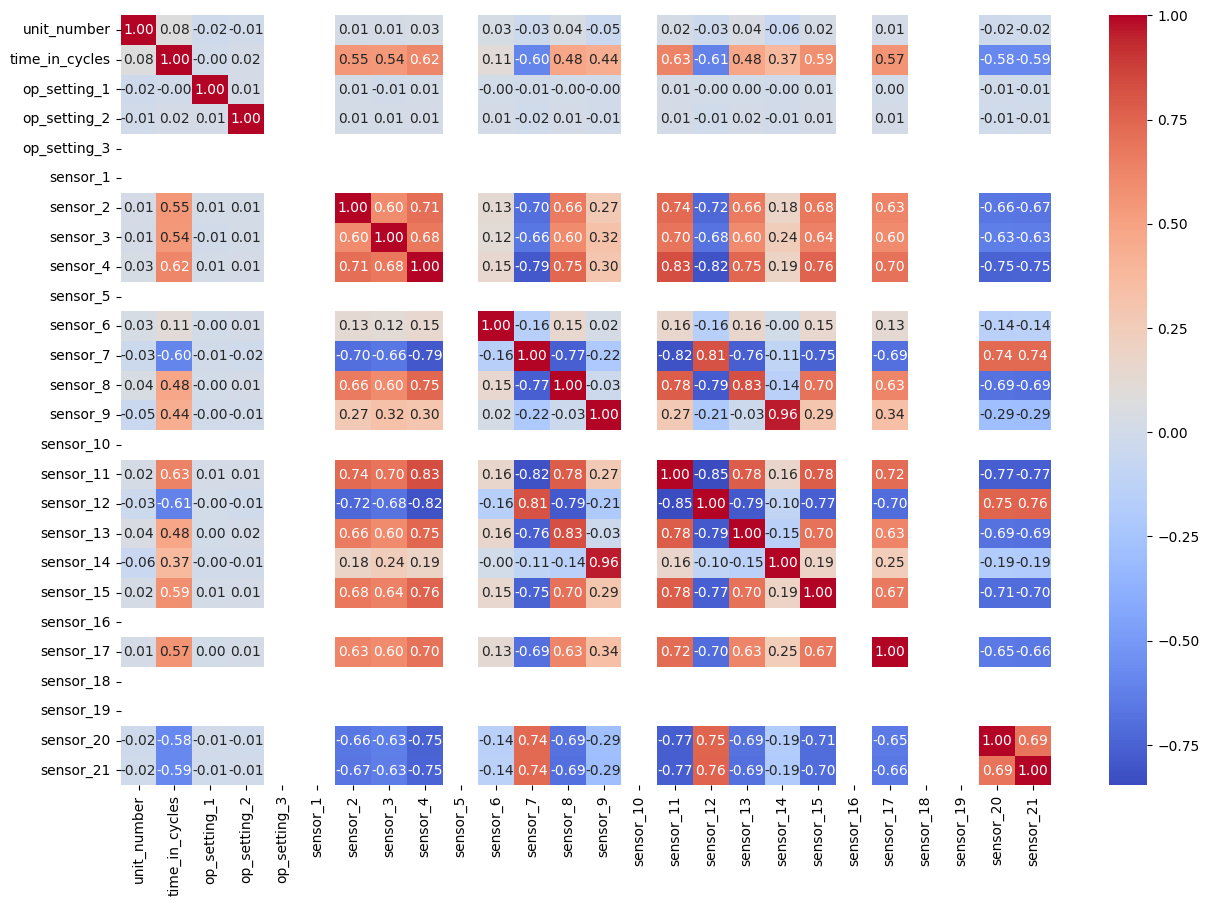

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

#corr = df.corr()

#rul_corr = corr['RUL'].sort_values(ascending=False)

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

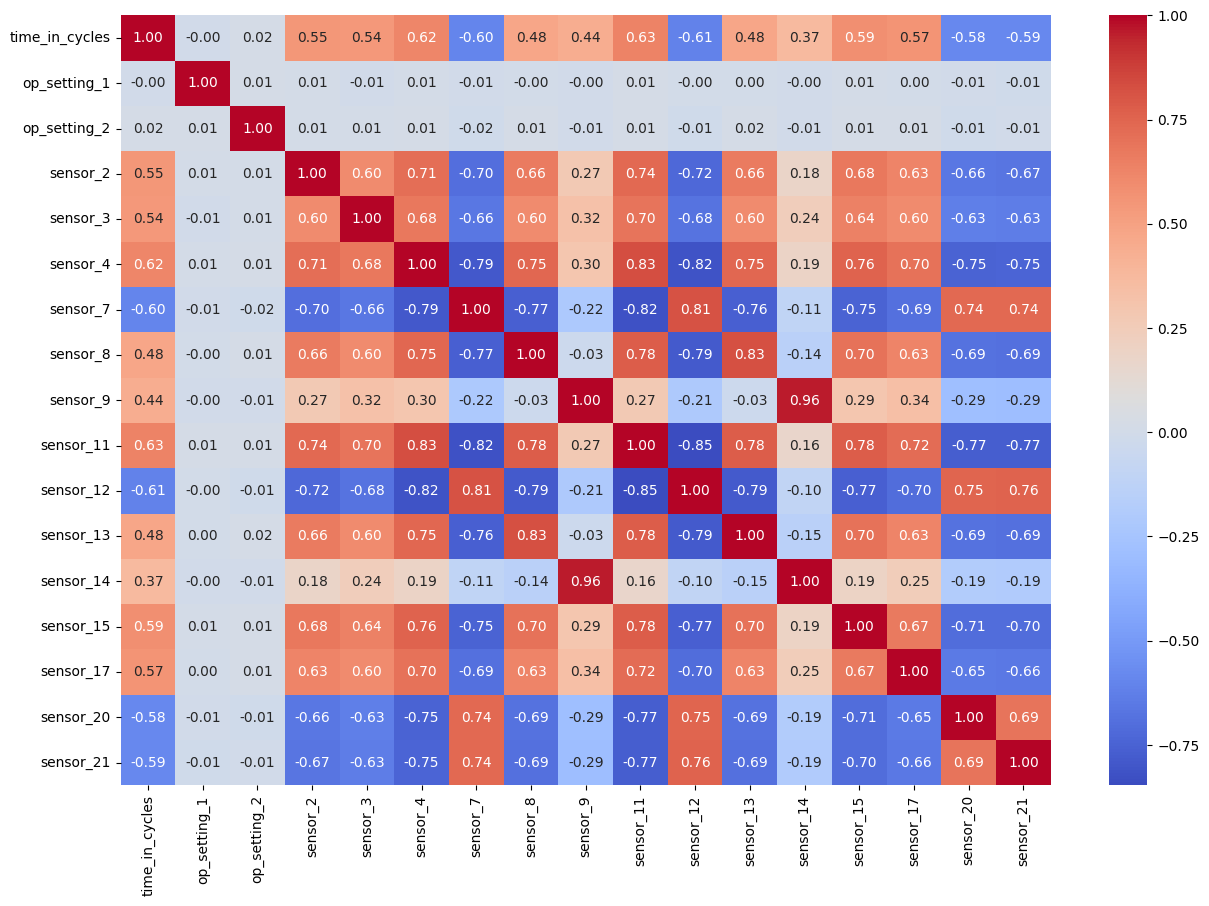

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. 제거할 컬럼 리스트 (물리량 명칭 기준)
# 값이 변하지 않아 분석에 의미가 없는 변수들을 제외합니다.
drop_cols = ['unit_number', 'op_setting_3','sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'] 

df = train_df.drop(columns=drop_cols, errors='ignore') # 없는 이름은 무시하도록 설정

plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [47]:
# 2. Test 데이터에서 각 엔진(unit_number)의 마지막 타임스텝만 추출
test_last_cyclce = test_df.groupby('unit_number').last().reset_index()

# 3. 추출된 마지막 데이터와 실제 RUL 정답 결합
test_with_rul = pd.merge(test_last_cyclce, rul_df, on='unit_number')

# 4. 분석에 사용하지 않을 컬럼 제거 (Train 데이터와 동일한 기준)
X_train = train_df.drop(columns=drop_cols, errors='ignore') # 학습 대상 features
X_test = test_with_rul.drop(columns=drop_cols + ['RUL'], errors='ignore') # 테스트 대상 features
y_test = test_with_rul['RUL'] # 테스트 실제 정답

# 5. StandardScaler 적용
scaler = StandardScaler()

# Train 데이터로 학습하고 변환
X_train_scaled = scaler.fit_transform(X_train)

# Test 데이터는 Train의 기준으로 변환만 수행 (Data Leakage 방지)
X_test_scaled = scaler.transform(X_test)

print("Scaled Train Shape:", X_train_scaled.shape)
print("Scaled Test Shape:", X_test_scaled.shape)

Scaled Train Shape: (20631, 17)
Scaled Test Shape: (100, 17)
